<a href="https://colab.research.google.com/github/songyanzhu/geoAI/blob/main/JupyterNotebooks/GGES6030_202627/GGES6030_P2_Functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GGES6030: Programming for Geospatial Data Science
## Week 2: Reproducible Code — Functions and Classes

<!-- ![GeoXAI Logo](https://raw.githubusercontent.com/songyanzhu/geoxai/main/resources/GeoXAI_logo.png) -->

<a href="https://github.com/soonyenju/geoAI">
  <img src="https://raw.githubusercontent.com/songyanzhu/geoxai/main/resources/GeoXAI_logo.png" width="300" alt="GeoXAI Logo">
</a>


Author: Songyan.Zhu@soton.ac.uk | University of Southampton, UK

License: CC BY-NC

---

**Learning Objectives**

1. Understand why modular code matters
2. Know how to write clean, functional code
3. Get a glimpse of Object-Oriented Programming (OOP)

# Why Do We Need Functions?

Think you want to calculate the distrance from two points $A(x_1, y_1)$ and $B(x_2, y_2)$.:

<a>
  <img src="https://raw.githubusercontent.com/songyanzhu/geoAI/main/JupyterNotebooks/GGES6030_202627/resources/Euclidean_Distance.jpg" width="800" alt="GeoXAI Logo">
</a>


In a 2D space, the straight-line distance between two points in a Cartesian coordinate system (such as planar projected coordinates like British National Grid, EPSG:27700), i.e., the Euclidean distance can be simply derived from the Pythagorean theorem:

$$d = \sqrt{\Delta x^2 + \Delta y^2}$$

Where $\Delta x = x_2 - x_1$ and $\Delta y = y_2 - y_1$

In [ ]:
# Define & assign values to variables
x1 = 2; x2 = 6
y1 = 3; y2 = 6

In [ ]:
# Calculate the differences along the Easting / X-axis and the Northing / Y-axis.
dx = x2 - x1
dy = y2 - y1

print(dx, dy)

4 3


In [ ]:
# Calclate the squared distance d2
d2 = dx * dx + dy * dy

print(d2)

25


So the answer is 5, right? On paper, that’s super simple. But how does a computer actually calculate that? And more importantly, what happens if Point A stays at (2, 3), but Point B moves to (5, 5)?"

<a>
  <img src="https://raw.githubusercontent.com/songyanzhu/geoAI/main/JupyterNotebooks/GGES6030_202627/resources/Euclidean_Distance_PointBNew.png" width="500" alt="GeoXAI Logo">
</a>


In [ ]:
x1 = 2; y1 = 3
x2 = 5; y2 = 5

dx = x2 - x1
dy = y2 - y1
d2 = dx * dx + dy * dy

print(d2)

13


So, what's the distance now?

Computers operate entirely on binary (0s and 1s). Under the hood, basic arithmetic is straightforward:

<a>
  <img src="https://raw.githubusercontent.com/songyanzhu/geoAI/main/JupyterNotebooks/GGES6030_202627/resources/How_computers_work.jpg" width="800" alt="GeoXAI Logo">
</a>


Addition is native:$$1 + 3 = 1 + 1 + 1 + 1$$Multiplication is simply repeated addition:$$2 \times 3 = (1 + 1 + 1) + (1 + 1 + 1)$$Both you and the computer can compute $51 + 12$ in a fraction of a second, and $12 \times 11$ without much trouble.

But what happens when we need a square root? Unlike addition and multiplication, a computer cannot solve $\sqrt{x}$ in a single elementary step.

Instead of writing all this low-level logic from scratch, Python lets us use functions i.e., pre-packaged tools built and battle-tested by others. There is no need to **reinvent the wheel**; we can simply **call** them to do the heavy lifting:

In [ ]:
import math

d = math.sqrt(d2)
print(d)

3.605551275463989


Now, what if you have 100 points to calcuate the distances?

# Writing Clean, Reusable Functions

<a>
  <img src="https://raw.githubusercontent.com/songyanzhu/geoAI/main/JupyterNotebooks/GGES6030_202627/resources/Newton-Raphson_iterative.png" width="800" alt="GeoXAI Logo">
</a>


The Python function calculates the square root of a positive number using the Newton-Raphson method.

Starting with an initial `guess`, it repeatedly averages guess and `x / guess` until the change between steps falls below the specified tolerance. In just a few fast iterations, it returns an accurate result, raising an error if given a negative input.

In [ ]:
def newton_raphson(x: float, tolerance: float = 1e-10, max_iter: int = 100) -> float:
    """Calculate square root using the Newton-Raphson iterative method."""
    if x < 0:
        raise ValueError("Cannot calculate square root of a negative number.")
    if x == 0:
        return 0.0

    # Initial guess
    guess = x / 2.0

    for _ in range(max_iter):
        next_guess = 0.5 * (guess + x / guess)
        if abs(next_guess - guess) < tolerance:
            return next_guess
        guess = next_guess

    return guess

# Example:
print(newton_raphson(25))
print(newton_raphson(13))

5.0
3.6055512754639896


## 🛠️ How to Write a Clean, Robust Function in Python

Writing a function isn't just about making code work—it's about making it **reusable, self-explanatory, and maintainable** for yourself and others.

---

Here is a standard template following geospatial best practices (e.g., computing distance between two points):

<a>
  <img src="https://raw.githubusercontent.com/songyanzhu/geoAI/main/JupyterNotebooks/GGES6030_202627/resources/How_to_write_code.jpg" width="800" alt="GeoXAI Logo">
</a>

# Object-Oriented Programming (OOP)
A practical guide: bundling data (attributes) and behavior (methods) into reusable objects.

In [ ]:
# Procedural vs. OOP: Why use classes?
# Without OOP: variables and functions are detached
p1_id, p1_x, p1_y = "STN_A", 441200.0, 112300.0
p2_id, p2_x, p2_y = "STN_B", 442500.0, 111800.0


def calculate_dist(x1, y1, x2, y2):
    return ((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5


print("Procedural distance:", calculate_dist(p1_x, p1_y, p2_x, p2_y))

Procedural distance: 1392.838827718412


<a>
  <img src="https://raw.githubusercontent.com/songyanzhu/geoAI/main/JupyterNotebooks/GGES6030_202627/resources/How_to_write_class.jpg" width="800" alt="GeoXAI Logo">
</a>

A super simple exmaple:

In [ ]:
class SpatialPoint:

    def __init__(self, point_id, x, y):
        self.point_id = point_id
        self.x = x
        self.y = y

    def distance_to(self, other):
        return ((other.x - self.x) ** 2 + (other.y - self.y) ** 2) ** 0.5

    def create_buffer(self, distance):
        return {
            "min_x": self.x - distance,
            "min_y": self.y - distance,
            "max_x": self.x + distance,
            "max_y": self.y + distance,
        }

In [ ]:
# 1. Instantiate two spatial points
p1 = SpatialPoint("Site_A", 2, 3)
p2 = SpatialPoint("Site_B", 5, 5)

# 2. Calculate the distance from p1 to p2
dist = p1.distance_to(p2)
print("Distance:", dist)

# 3. Generate a 500-meter buffer bounding box around p1
buffer_box = p1.create_buffer(1)
print("Buffer Bounding Box:", buffer_box)

Distance: 3.61
Buffer Bounding Box: {'center': (2.0, 3.0), 'radius': 1, 'bbox': {'min_x': 1.0, 'min_y': 2.0, 'max_x': 3.0, 'max_y': 4.0}, 'polygon_coords': [(3.0, 3.0), (2.98, 3.17), (2.94, 3.34), (2.87, 3.5), (2.77, 3.64), (2.64, 3.77), (2.5, 3.87), (2.34, 3.94), (2.17, 3.98), (2.0, 4.0), (1.83, 3.98), (1.66, 3.94), (1.5, 3.87), (1.36, 3.77), (1.23, 3.64), (1.13, 3.5), (1.06, 3.34), (1.02, 3.17), (1.0, 3.0), (1.02, 2.83), (1.06, 2.66), (1.13, 2.5), (1.23, 2.36), (1.36, 2.23), (1.5, 2.13), (1.66, 2.06), (1.83, 2.02), (2.0, 2.0), (2.17, 2.02), (2.34, 2.06), (2.5, 2.13), (2.64, 2.23), (2.77, 2.36), (2.87, 2.5), (2.94, 2.66), (2.98, 2.83), (3.0, 3.0)]}


**Inheritance** allows a subclass to inherit attributes and methods from a parent class, enabling code reuse and extending functionality without duplication.

In [ ]:
# Inherit and override the buffer method to generate a circular buffer
class CircularSpatialPoint(SpatialPoint):

    def create_buffer(self, distance, num_vertices=36):
        """Generate a circular buffer approximated by discrete boundary coordinates."""
        coords = []
        for i in range(num_vertices):
            angle = 2 * math.pi * (i / num_vertices)
            px = round(self.x + distance * math.cos(angle), 2)
            py = round(self.y + distance * math.sin(angle), 2)
            coords.append((px, py))
        coords.append(coords[0])  # Close the polygon loop

        return {
            "center": (self.x, self.y),
            "radius": distance,
            "polygon": coords,
        }

In [ ]:
# 1. Instantiate two spatial points
p1 = CircularSpatialPoint("Site_A", 2, 3)
p2 = CircularSpatialPoint("Site_B", 5, 5)

# 2. Calculate the distance from p1 to p2 (inherited from SpatialPoint)
dist = p1.distance_to(p2)
print("Distance:", dist)

# 3. Generate a circular buffer of radius 1 (using 8 vertices for a compact print)
circle_buffer = p1.create_buffer(1, num_vertices=36)
print("Circular Buffer:")
print("Center:", circle_buffer["center"])
print("Radius:", circle_buffer["radius"])
print("Polygon Vertices:", circle_buffer["polygon"])

Distance: 3.61
Circular Buffer:
Center: (2.0, 3.0)
Radius: 1
Polygon Vertices: [(3.0, 3.0), (2.98, 3.17), (2.94, 3.34), (2.87, 3.5), (2.77, 3.64), (2.64, 3.77), (2.5, 3.87), (2.34, 3.94), (2.17, 3.98), (2.0, 4.0), (1.83, 3.98), (1.66, 3.94), (1.5, 3.87), (1.36, 3.77), (1.23, 3.64), (1.13, 3.5), (1.06, 3.34), (1.02, 3.17), (1.0, 3.0), (1.02, 2.83), (1.06, 2.66), (1.13, 2.5), (1.23, 2.36), (1.36, 2.23), (1.5, 2.13), (1.66, 2.06), (1.83, 2.02), (2.0, 2.0), (2.17, 2.02), (2.34, 2.06), (2.5, 2.13), (2.64, 2.23), (2.77, 2.36), (2.87, 2.5), (2.94, 2.66), (2.98, 2.83), (3.0, 3.0)]


Let's see the outcomes

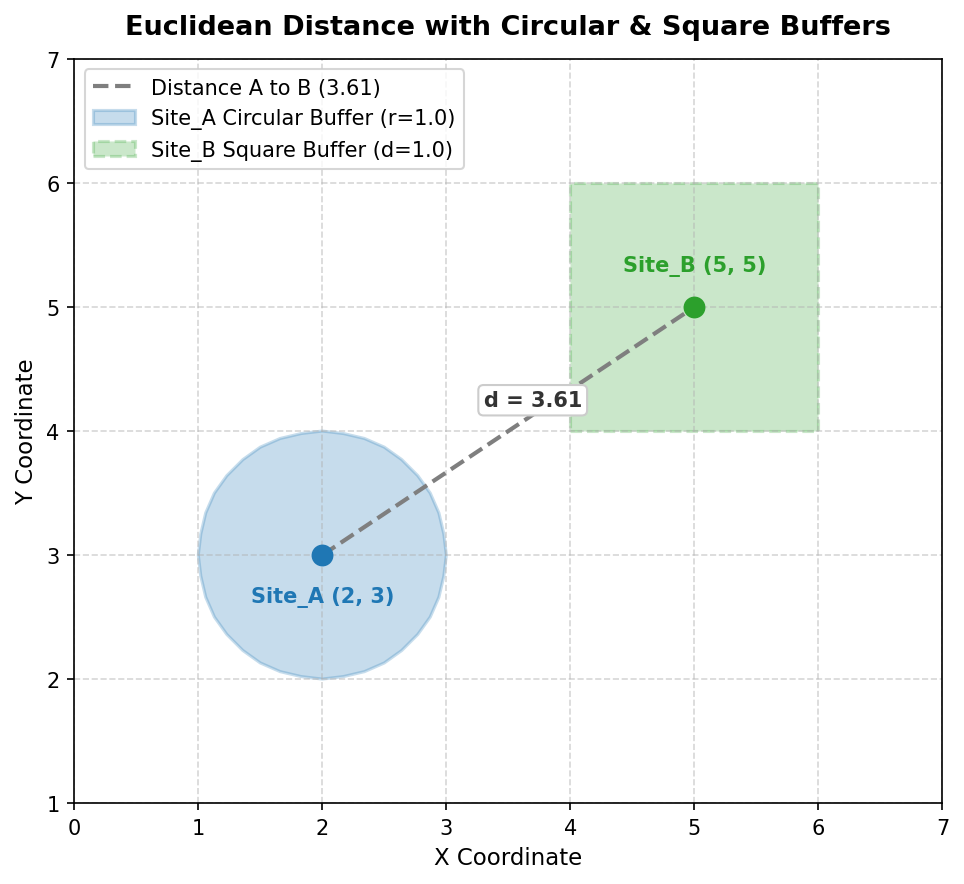

In [ ]:
import math
import matplotlib.patches as patches
import matplotlib.pyplot as plt

# =====================================================================
# Matplotlib Visualization (English Annotations)
# =====================================================================
fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, 7)
ax.set_ylim(1, 7)

# 1) Draw Euclidean distance line between A and B
ax.plot(
    [p1.x, p2.x],
    [p1.y, p2.y],
    color="#7f7f7f",
    linestyle="--",
    linewidth=2,
    label=f"Distance A to B ({dist:.2f})",
)

# 2) Draw Circular Buffer around Site_A (p1)
circle_patch = patches.Polygon(
    circle_buffer["polygon"],
    closed=True,
    facecolor="#1f77b4",
    edgecolor="#1f77b4",
    alpha=0.25,
    linestyle="-",
    linewidth=1.5,
    label="Site_A Circular Buffer (r=1.0)",
)
ax.add_patch(circle_patch)

# 3) Draw Square Bounding Box Buffer around Site_B (p2)
# Width = max_x - min_x = 2 * dist, Height = max_y - min_y = 2 * dist
rect_width = buffer_box['bbox']["max_x"] - buffer_box['bbox']["min_x"]
rect_height = buffer_box['bbox']["max_y"] - buffer_box['bbox']["min_y"]
square_patch = patches.Rectangle(
    (buffer_box['bbox']["min_x"], buffer_box['bbox']["min_y"]),
    rect_width,
    rect_height,
    facecolor="#2ca02c",
    edgecolor="#2ca02c",
    alpha=0.25,
    linestyle="--",
    linewidth=1.5,
    label="Site_B Square Buffer (d=1.0)",
)
ax.add_patch(square_patch)

# 4) Scatter points
ax.scatter([p1.x], [p1.y], color="#1f77b4", s=90, zorder=5)
ax.scatter([p2.x], [p2.y], color="#2ca02c", s=90, zorder=5)

# 5) Labels and English text annotations
ax.text(
    p1.x,
    p1.y - 0.25,
    f"{p1.point_id} (2, 3)",
    ha="center",
    va="top",
    fontweight="bold",
    color="#1f77b4",
)
ax.text(
    p2.x,
    p2.y + 0.25,
    f"{p2.point_id} (5, 5)",
    ha="center",
    va="bottom",
    fontweight="bold",
    color="#2ca02c",
)

# Annotate distance value along the midpoint
mid_x, mid_y = (p1.x + p2.x) / 2, (p1.y + p2.y) / 2
ax.text(
    mid_x - 0.2,
    mid_y + 0.2,
    f"d = {dist:.2f}",
    color="#333333",
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.25", facecolor="white", edgecolor="#cccccc"
    ),
)

# Figure metadata (English)
ax.set_title(
    "Euclidean Distance with Circular & Square Buffers",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("X Coordinate", fontsize=11)
ax.set_ylabel("Y Coordinate", fontsize=11)
ax.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

Complete example of proper code

In [ ]:
import math


class SpatialPoint:
    """Represents a 2D spatial point feature with distance calculation

    and buffer generation capabilities.
    """

    def __init__(
        self,
        point_id: str,
        x: float,
        y: float,
        crs: str = "EPSG:27700",
    ):
        """Initialize a SpatialPoint instance.

        Parameters
        ----------
        point_id : str
            Unique identifier for the point feature.
        x : float
            Planar X-coordinate (e.g., Easting).
        y : float
            Planar Y-coordinate (e.g., Northing).
        crs : str, optional
            Coordinate Reference System (default is 'EPSG:27700').
        """
        self.point_id = str(point_id)
        self.x = float(x)
        self.y = float(y)
        self.crs = crs

    def distance_to(
        self, other: "SpatialPoint", round_digits: int = 2
    ) -> float:
        """Calculate the 2D Euclidean distance to another SpatialPoint.

        Parameters
        ----------
        other : SpatialPoint
            The target point instance.
        round_digits : int, optional
            Number of decimal places to round the distance (default is 2).

        Returns
        -------
        float
            Straight-line distance in coordinate units (e.g., meters).
        """
        if not isinstance(other, SpatialPoint):
            raise TypeError("Target must be an instance of SpatialPoint.")

        if self.crs != other.crs:
            raise ValueError(f"CRS mismatch: {self.crs} vs {other.crs}")

        dx = other.x - self.x
        dy = other.y - self.y
        distance = math.sqrt(dx**2 + dy**2)
        return round(distance, round_digits)

    def create_buffer(
        self, distance: float, num_vertices: int = 36
    ) -> dict[str, any]:
        """Generate a circular buffer around the point.

        Parameters
        ----------
        distance : float
            Buffer radius in coordinate units (must be > 0).
        num_vertices : int, optional
            Number of vertices used to approximate the circle boundary (default is 36).

        Returns
        -------
        dict
            Dictionary containing buffer geometry attributes:
            - 'center': (x, y) coordinates of the center point.
            - 'radius': Buffer radius.
            - 'bbox': Bounding box {'min_x', 'min_y', 'max_x', 'max_y'}.
            - 'polygon_coords': Closed list of boundary coordinates [(x, y), ...].
        """
        if distance <= 0:
            raise ValueError("Buffer distance must be strictly positive.")

        # 1. Bounding box extent
        bbox = {
            "min_x": round(self.x - distance, 2),
            "min_y": round(self.y - distance, 2),
            "max_x": round(self.x + distance, 2),
            "max_y": round(self.y + distance, 2),
        }

        # 2. Approximate circular boundary vertices
        polygon_coords = []
        for i in range(num_vertices):
            angle = 2 * math.pi * (i / num_vertices)
            px = self.x + distance * math.cos(angle)
            py = self.y + distance * math.sin(angle)
            polygon_coords.append((round(px, 2), round(py, 2)))

        # Close the polygon loop
        polygon_coords.append(polygon_coords[0])

        return {
            "center": (self.x, self.y),
            "radius": distance,
            "bbox": bbox,
            "polygon_coords": polygon_coords,
        }

    def __repr__(self) -> str:
        """Return a readable string representation of the instance."""
        return f"SpatialPoint(id='{self.point_id}', x={self.x}, y={self.y}, crs='{self.crs}')"

# # =====================================================================
# # Use Example
# # =====================================================================

# pt_a = SpatialPoint("Station_A", 441200.0, 112300.0)
# pt_b = SpatialPoint("Station_B", 442500.0, 111800.0)

# print("Point Representation:", pt_a)

# # 1. Distance measurement
# dist = pt_a.distance_to(pt_b)
# print(f"Distance from {pt_a.point_id} to {pt_b.point_id}: {dist} m")

# # 2. Buffer generation
# buffer_result = pt_a.create_buffer(distance=500.0)
# print("Buffer Bounding Box:", buffer_result["bbox"])
# print(f"Generated Vertices Count: {len(buffer_result['polygon_coords'])}")
# print("First 3 Vertices:", buffer_result["polygon_coords"][:3])

# 📝 Week 2 Exercise: Find the Nearest Point

## Objective
In this exercise, you will practice writing **reusable functions** with explicit arguments, type hints, docstrings, and `return` values.

**Important:** Do **not** use classes (`class`). Focus purely on clean function design.

---

## Task Description
You are given a reference point **A** and a list of 20 target points **B** (represented as 2D coordinates).

You need to implement two functions:
1. `calculate_distance(p1, p2)`: Calculates the straight-line (Euclidean) distance between any two points `p1` and `p2`.
2. `find_nearest_point(origin, targets)`: Iterates through all target points, uses `calculate_distance()` to measure the distance to each, and finds the closest point along with its distance.

---

## Starter Template

```python
import math


def calculate_distance(p1: tuple[float, float], p2: tuple[float, float]) -> float:
  """Calculate the 2D Euclidean distance between two points."""
  # TODO: Implement distance calculation
  # Hint: ((x2 - x1)**2 + (y2 - y1)**2) ** 0.5
  pass


def find_nearest_point(
    origin: tuple[float, float], targets: list[tuple[float, float]]
) -> tuple[tuple[float, float], float]:
  """Find the closest point to the origin from a list of targets.

  Parameters:
  -----------
  origin : tuple of (float, float)
      The reference coordinate (point A).
  targets : list of tuple of (float, float)
      A list of candidate coordinates (points B).

  Returns:
  --------
  tuple: (nearest_point, min_distance)
      The coordinate pair of the nearest point and the distance to it (rounded
      to 2 decimal places).
  """
  # TODO: Iterate through targets, find the minimum distance, and return
  pass


# -------------------------------------------------------------
# Test Data (Point A and 20 Points B)
# -------------------------------------------------------------
if __name__ == "__main__":
  # Reference point A
  point_a = (432500.0, 115200.0)

  # 20 target locations (B points)
  points_b = [
      (433100.0, 116000.0),
      (435000.0, 117500.0),
      (431800.0, 114900.0),
      (432900.0, 115600.0),
      (434200.0, 116800.0),
      (430500.0, 113800.0),
      (432200.0, 115100.0),
      (433800.0, 116400.0),
      (436000.0, 118200.0),
      (431200.0, 114500.0),
      (432600.0, 115300.0),
      (433500.0, 116100.0),
      (434800.0, 117200.0),
      (431900.0, 115000.0),
      (432400.0, 115150.0),
      (433300.0, 115900.0),
      (435500.0, 117800.0),
      (430900.0, 114200.0),
      (432700.0, 115400.0),
      (434000.0, 116600.0),
  ]

  nearest_pt, min_dist = find_nearest_point(point_a, points_b)
  print(f"Nearest Point to A: {nearest_pt}")
  print(f"Distance: {min_dist} m")